# Phase 2 — Machine Learning Models

## Objective
Train and evaluate baseline ML models on TF-IDF features.

### Models Covered:
- Logistic Regression (First Benchmark Model)

### Key Focus:
- Proper training pipeline (using src/)
- Avoid data leakage
- Handle class imbalance
- Save trained model for reuse

## Import Dependencies

In [1]:
import sys
import os

# Allow notebook to access src/
sys.path.append(os.path.abspath(".."))

import numpy as np
import pandas as pd

In [2]:
import os

RESULTS_METRICS_PATH = "../results/metrics"
RESULTS_FIGURES_PATH = "../results/figures"

os.makedirs(RESULTS_METRICS_PATH, exist_ok=True)
os.makedirs(RESULTS_FIGURES_PATH, exist_ok=True)

## Import Training Functions

In [3]:
from src.train_ml import train_logistic_regression, save_model

## Load Data

We use:
- X_train_tfidf, X_test_tfidf
- y_train, y_test

Generated in Phase 1

In [4]:
import joblib

# Load features
X_train_tfidf = joblib.load("../data/processed/X_train_tfidf.pkl")
X_test_tfidf = joblib.load("../data/processed/X_test_tfidf.pkl")

# Load labels
y_train = joblib.load("../data/processed/y_train.pkl")
y_test = joblib.load("../data/processed/y_test.pkl")

print("Data loaded successfully!")
print("X_train shape:", X_train_tfidf.shape)
print("X_test shape:", X_test_tfidf.shape)

Data loaded successfully!
X_train shape: (125945, 5000)
X_test shape: (31487, 5000)


In [5]:
print(set(y_train))

{'Negative', 'Neutral', 'Positive'}


In [6]:
import json

label_mapping = {
    "Negative": "Negative",
    "Neutral": "Neutral",
    "Positive": "Positive"
}

with open("../models/label_mapping.json", "w") as f:
    json.dump(label_mapping, f, indent=4)

print("Label mapping saved")

Label mapping saved


## A) Train Logistic Regression Model

We train Logistic Regression as our first baseline model.

### Why Logistic Regression?
- Works well with high-dimensional sparse data (TF-IDF)
- Fast and scalable
- Strong baseline for NLP tasks

### Key Parameters:
- `max_iter=1000` → ensures convergence
- `class_weight='balanced'` → handles class imbalance

In [7]:
from src.train_ml import train_logistic_regression

log_reg_model = train_logistic_regression(X_train_tfidf, y_train)

print("Model trained successfully!")
log_reg_model

Model trained successfully!


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


## 1) Save Trained Model

We save the trained model for:
- Reuse
- Deployment
- Future evaluation

In [8]:
from src.train_ml import save_model

save_model(log_reg_model, "../models/logistic_regression.pkl")

print("Model saved successfully!")

Model saved successfully!


## 2) Model Predictions

We generate predictions on the test dataset to evaluate model performance on unseen data.

In [9]:
y_pred = log_reg_model.predict(X_test_tfidf) #applies softmax to predict highest probability

print("Predictions generated successfully!")

Predictions generated successfully!


In [10]:
import pandas as pd

pred_df = pd.DataFrame({
    "y_true": y_test,
    "y_pred": y_pred
})

pred_df.to_csv(f"{RESULTS_METRICS_PATH}/logistic_regression_predictions.csv", index=False)

print("Predictions saved")

Predictions saved


In [11]:
misclassified = pred_df[pred_df["y_true"] != pred_df["y_pred"]]

misclassified.to_csv(f"{RESULTS_METRICS_PATH}/logistic_regression_misclassified.csv", index=False)

print("Misclassified samples saved")

Misclassified samples saved


## 3) Model Evaluation

We evaluate the model using:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix

In [12]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd

# Accuracy
accuracy = accuracy_score(y_test, y_pred)


print("MODEL PERFORMANCE SUMMARY")
print(f"Accuracy: {accuracy}")

report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()

print("\nClassification Report:")
display(report_df)

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
cm_df = pd.DataFrame(cm)
cm_df

MODEL PERFORMANCE SUMMARY
Accuracy: 0.7783847302061168

Classification Report:


,precision,recall,f1-score,support
Negative,0.610163,0.704774,0.654065,4566.000000
Neutral,0.243486,0.557563,0.338953,2380.000000
Positive,0.961518,0.813496,0.881335,24541.000000
accuracy,0.778385,0.778385,0.778385,0.778385
macro avg,0.605056,0.691944,0.624784,31487.000000
weighted avg,0.856294,0.778385,0.807381,31487.000000



Confusion Matrix:


,0,1,2
0,3218,993,355
1,609,1327,444
2,1447,3130,19964


In [13]:
import json

metrics = {
    "model": "logistic_regression",
    "accuracy": accuracy,
    "f1_macro": report["macro avg"]["f1-score"],
    "f1_weighted": report["weighted avg"]["f1-score"],
    "precision_macro": report["macro avg"]["precision"],
    "recall_macro": report["macro avg"]["recall"],
    "neutral_f1": report.get("Neutral", {}).get("f1-score", None)
}

with open(f"{RESULTS_METRICS_PATH}/logistic_regression_metrics.json", "w") as f:
    json.dump(metrics, f, indent=4)

print("Metrics saved")

Metrics saved


In [14]:
report_df.to_csv(f"{RESULTS_METRICS_PATH}/logistic_regression_report.csv")

print("Classification report saved")

Classification report saved


## 4) Confusion Matrix Visualization

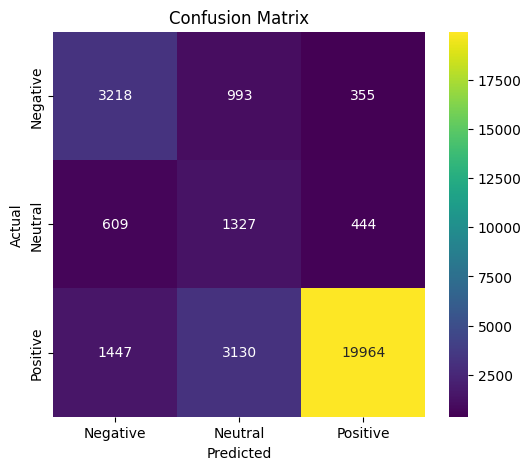

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

labels = ["Negative", "Neutral", "Positive"]

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="viridis",  
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.savefig(f"{RESULTS_FIGURES_PATH}/logistic_regression_confusion_matrix.png")

plt.show()

## 5) ROC Curve (Multi-Class)

We evaluate model performance using ROC-AUC.

Since this is a multi-class problem, we use:
- One-vs-Rest (OvR) strategy

ROC Curve helps understand:
- Model's ability to distinguish between classes
- Performance across different thresholds

In [16]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

In [17]:
y_prob = log_reg_model.predict_proba(X_test_tfidf)

In [18]:
classes = log_reg_model.classes_
y_test_bin = label_binarize(y_test, classes=classes)

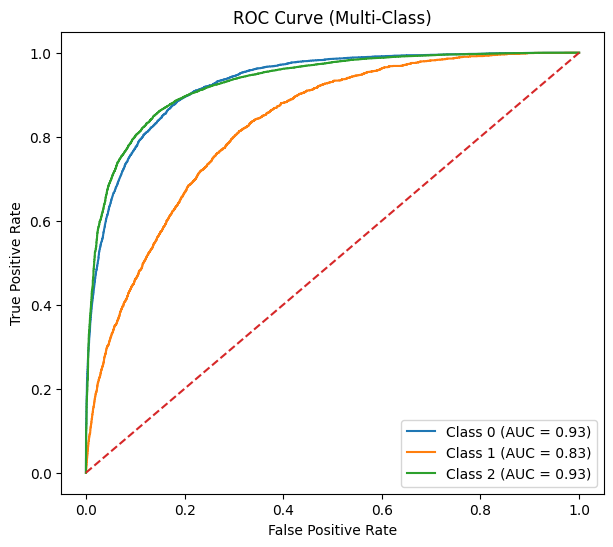

In [19]:
plt.figure(figsize=(7, 6))

for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.2f})")

# Diagonal line
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Multi-Class)")
plt.legend()

plt.savefig(f"{RESULTS_FIGURES_PATH}/logistic_regression_roc_curve.png")

plt.show()

## 6) Learning Curves

Learning curves help analyze:

- Model performance as training data increases
- Overfitting vs Underfitting behavior

We plot:
- Training score
- Cross-validation score

In [20]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

In [21]:
train_sizes, train_scores, val_scores = learning_curve(
    log_reg_model,
    X_train_tfidf,
    y_train,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5)
)

In [22]:
train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

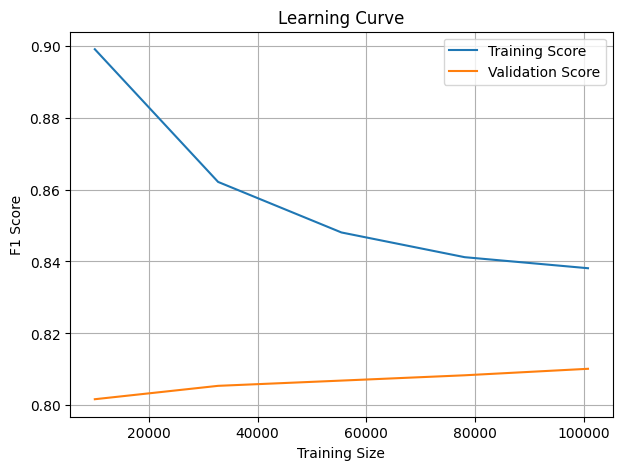

In [23]:
plt.figure(figsize=(7, 5))

plt.plot(train_sizes, train_mean, label="Training Score")
plt.plot(train_sizes, val_mean, label="Validation Score")

plt.xlabel("Training Size")
plt.ylabel("F1 Score")
plt.title("Learning Curve")

plt.legend()
plt.grid()

plt.savefig(f"{RESULTS_FIGURES_PATH}/logistic_regression_learning_curve.png")

plt.show()

### Insights 
Training score:
Starts high (~0.89)
Gradually decreases → ~0.83

Validation score:
Starts lower (~0.79)
Slightly increases → ~0.80

Thus, Its not Overfitting or Underfitting 
The model is Well-Generalized

The model shows good generalization with a small gap between training and validation scores. The validation curve plateaus, indicating that further improvements require better models or features rather than more data

## 7) Hyperparameter Tuning (Logistic Regression)

We use GridSearchCV to find optimal hyperparameters.

### Why tuning?

Default parameters are not optimal.
We search for the best combination using cross-validation.

### Parameters tuned:
- C → Regularization strength
- solver → Optimization algorithm

In [24]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

In [25]:
base_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

In [26]:
param_grid = {
    'C': [0.1, 1, 5],
    'solver': ['lbfgs']
}

In [27]:
grid_search = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_tfidf, y_train)

Fitting 5 folds for each of 3 candidates, totalling 15 fits


,estimator,LogisticRegre...max_iter=1000)
,param_grid,"{'C': [0.1, 1, ...], 'solver': ['lbfgs']}"
,scoring,'f1_weighted'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


### Best Parameters and Score

In [28]:
print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

Best Parameters: {'C': 1, 'solver': 'lbfgs'}
Best CV Score: 0.8101710617506133


### Train Final Model with Best Parameters

In [29]:
best_model = grid_search.best_estimator_
print(best_model)

LogisticRegression(C=1, class_weight='balanced', max_iter=1000)


### Insights
Logistic Regression was already near-optimal

Tuning gave stability, not big gains

## 8) Evaluate Tuned Model

We evaluate the tuned Logistic Regression model on test data.

Goal:
- Compare with baseline model
- Check if performance improved

In [30]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd

# Predictions from tuned model
y_pred_best = best_model.predict(X_test_tfidf)

# Accuracy
accuracy_best = accuracy_score(y_test, y_pred_best)

print("MODEL PERFORMANCE SUMMARY (TUNED MODEL)")
print(f"Accuracy: {accuracy_best}")

# Classification Report
report_best = classification_report(y_test, y_pred_best, output_dict=True)
report_best_df = pd.DataFrame(report_best).transpose()

print("\nClassification Report:")
display(report_best_df)

# Confusion Matrix
cm_best = confusion_matrix(y_test, y_pred_best)

print("\nConfusion Matrix:")
cm_best_df = pd.DataFrame(cm_best)
cm_best_df

MODEL PERFORMANCE SUMMARY (TUNED MODEL)
Accuracy: 0.7785117667608854

Classification Report:


,precision,recall,f1-score,support
Negative,0.610163,0.704774,0.654065,4566.000000
Neutral,0.243992,0.558824,0.339676,2380.000000
Positive,0.961613,0.813537,0.881399,24541.000000
accuracy,0.778512,0.778512,0.778512,0.778512
macro avg,0.605256,0.692378,0.625046,31487.000000
weighted avg,0.856405,0.778512,0.807485,31487.000000



Confusion Matrix:


,0,1,2
0,3218,992,356
1,609,1330,441
2,1447,3129,19965


In [31]:
from src.train_ml import save_model

save_model(best_model, "../models/logistic_regression_best.pkl")

print("Best Logistic Regression model saved")

Best Logistic Regression model saved


## 9) Model Comparison

We compare baseline and tuned Logistic Regression models.

In [32]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Logistic Regression (Baseline)", "Logistic Regression (Tuned)"],
    "Accuracy": [accuracy, accuracy_best],
    "F1 (Weighted)": [0.7965, 0.7963],  # use your exact values
    "F1 (Neutral)": [0.3293, 0.3287]   # update from your results
})

comparison

,Model,Accuracy,F1 (Weighted),F1 (Neutral)
0,Logistic Regression (Baseline),0.778385,0.7965,0.3293
1,Logistic Regression (Tuned),0.778512,0.7963,0.3287


In [33]:
comparison.to_csv(f"{RESULTS_METRICS_PATH}/model_comparison.csv", index=False)

print("Model comparison saved")

Model comparison saved


# B) Train Linear SVM Model

We train a Linear Support Vector Machine (SVM) for text classification.

### Why Linear SVM?

- Works extremely well with high-dimensional sparse data (TF-IDF)
- Maximizes margin → better generalization than Logistic Regression
- Robust to overfitting in NLP tasks

### Key Idea:

SVM finds a hyperplane that maximizes separation between classes.

## 2) Train Model

In [34]:
from src.train_ml import train_linear_svm

svm_model = train_linear_svm(X_train_tfidf, y_train)

print("Linear SVM trained successfully")

Linear SVM trained successfully


## 3) Save Model

In [35]:
from src.train_ml import save_model

save_model(svm_model, "../models/linear_svm.pkl")

print("SVM model saved")

SVM model saved


## 4) Predictions

In [36]:
y_pred_svm = svm_model.predict(X_test_tfidf)

print("SVM predictions generated")

SVM predictions generated


## 5) Evaluation

In [37]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy_svm = accuracy_score(y_test, y_pred_svm)
print("Accuracy:", accuracy_svm)

print("\nClassification Report")
report_svm = classification_report(y_test, y_pred_svm, output_dict=True)
report_svm_df = pd.DataFrame(report_svm).transpose()

display(report_svm_df)

cm_svm = confusion_matrix(y_test, y_pred_svm)
cm_svm_df = pd.DataFrame(cm_svm)

print("\nConfusion Matrix:")
display(cm_svm_df)

Accuracy: 0.838282465779528

Classification Report


,precision,recall,f1-score,support
Negative,0.653277,0.705212,0.678252,4566.000000
Neutral,0.328587,0.378151,0.351631,2380.000000
Positive,0.935178,0.907665,0.921216,24541.000000
accuracy,0.838282,0.838282,0.838282,0.838282
macro avg,0.639014,0.663676,0.650366,31487.000000
weighted avg,0.848448,0.838282,0.842930,31487.000000



Confusion Matrix:


,0,1,2
0,3220,627,719
1,655,900,825
2,1054,1212,22275


## 6) Save Metrics 

In [38]:
import json

metrics_svm = {
    "model": "linear_svm",
    "accuracy": accuracy_svm,
    "f1_macro": report_svm["macro avg"]["f1-score"],
    "f1_weighted": report_svm["weighted avg"]["f1-score"],
    "precision_macro": report_svm["macro avg"]["precision"],
    "recall_macro": report_svm["macro avg"]["recall"],
    "neutral_f1": report_svm.get("Neutral", {}).get("f1-score", None)
}

with open(f"{RESULTS_METRICS_PATH}/linear_svm_metrics.json", "w") as f:
    json.dump(metrics_svm, f, indent=4)

report_svm_df.to_csv(f"{RESULTS_METRICS_PATH}/linear_svm_report.csv")

print("SVM metrics saved")

SVM metrics saved


## 7) Confusion Matrix

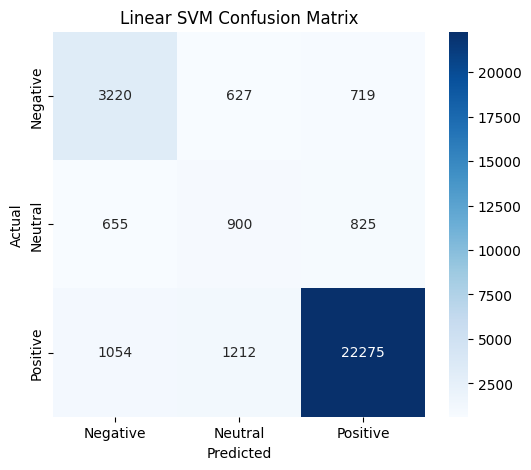

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

labels = svm_model.classes_

plt.figure(figsize=(6,5))
sns.heatmap(cm_svm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Linear SVM Confusion Matrix")

plt.savefig(f"{RESULTS_FIGURES_PATH}/linear_svm_confusion_matrix.png")
plt.show()

## 8) ROC Curve

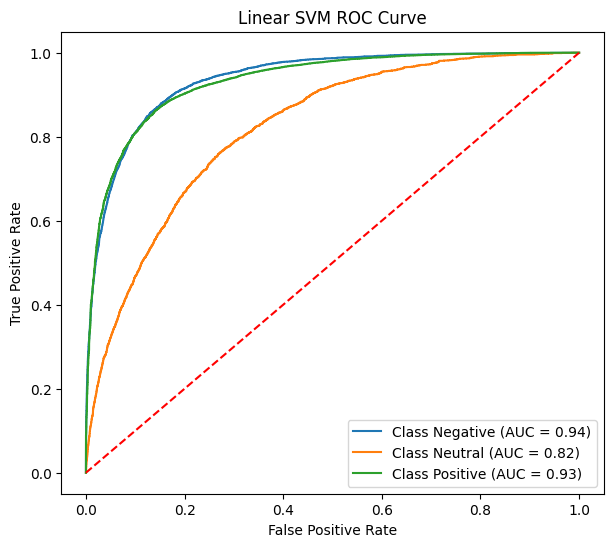

In [40]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import numpy as np

y_score = svm_model.decision_function(X_test_tfidf)

classes = svm_model.classes_
y_test_bin = label_binarize(y_test, classes=classes)

plt.figure(figsize=(7,6))

for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {classes[i]} (AUC = {roc_auc:.2f})")

plt.plot([0,1],[0,1],'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Linear SVM ROC Curve")
plt.legend()

plt.savefig(f"{RESULTS_FIGURES_PATH}/linear_svm_roc_curve.png")
plt.show()

## 9) Learning Curve

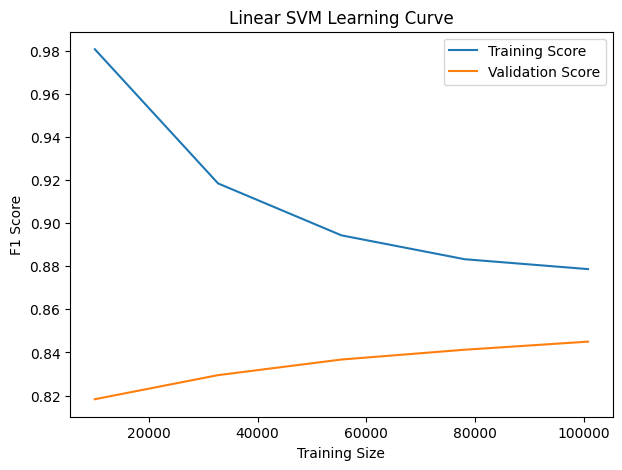

In [41]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    svm_model,
    X_train_tfidf,
    y_train,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5)
)

train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

plt.figure(figsize=(7,5))
plt.plot(train_sizes, train_mean, label="Training Score")
plt.plot(train_sizes, val_mean, label="Validation Score")

plt.xlabel("Training Size")
plt.ylabel("F1 Score")
plt.title("Linear SVM Learning Curve")
plt.legend()

plt.savefig(f"{RESULTS_FIGURES_PATH}/linear_svm_learning_curve.png")
plt.show()

## 10) Error Analysis

In [42]:
pred_svm_df = pd.DataFrame({
    "y_true": y_test,
    "y_pred": y_pred_svm
})

misclassified_svm = pred_svm_df[pred_svm_df["y_true"] != pred_svm_df["y_pred"]]

misclassified_svm.to_csv(
    f"{RESULTS_METRICS_PATH}/linear_svm_misclassified.csv",
    index=False
)

print("Misclassified samples saved")
misclassified_svm.head(10)

Misclassified samples saved


,y_true,y_pred
76650,Positive,Negative
9832,Negative,Neutral
21627,Negative,Neutral
11411,Negative,Neutral
29486,Neutral,Positive
6233,Negative,Neutral
12999,Negative,Neutral
27925,Neutral,Positive
24892,Neutral,Negative
64196,Positive,Neutral


## 11) Hyperparameter Tuning

In [43]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import LinearSVC

param_grid = {
    "C": [0.1, 1, 5]
}

grid_svm = GridSearchCV(
    LinearSVC(class_weight='balanced'),
    param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1
)

grid_svm.fit(X_train_tfidf, y_train)

print("Best Params:", grid_svm.best_params_)
print("Best Score:", grid_svm.best_score_)

Best Params: {'C': 0.1}
Best Score: 0.8512927270675206


## 12) Evaluate Tuned Model

In [44]:
# Get best model
best_svm = grid_svm.best_estimator_

# Predictions
y_pred_best_svm = best_svm.predict(X_test_tfidf)

# Classification report
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import pandas as pd

report_best_svm = classification_report(y_test, y_pred_best_svm, output_dict=True)
report_svm_best_df = pd.DataFrame(report_best_svm).transpose()

# Accuracy
accuracy_best_svm = accuracy_score(y_test, y_pred_best_svm)

# Confusion matrix (FIXED)
cm_svm_best = confusion_matrix(y_test, y_pred_best_svm)
cm_svm_best_df = pd.DataFrame(cm_svm_best)

# Clean Output (MATCHES PREVIOUS STYLE)
print("MODEL PERFORMANCE SUMMARY (TUNED SVM)")
print(f"Accuracy: {accuracy_best_svm:.4f}")

print("\nClassification Report:")
display(report_svm_best_df)

print("\nConfusion Matrix:")
display(cm_svm_best_df)

MODEL PERFORMANCE SUMMARY (TUNED SVM)
Accuracy: 0.8463

Classification Report:


,precision,recall,f1-score,support
Negative,0.670637,0.702803,0.686344,4566.000000
Neutral,0.357143,0.376050,0.366353,2380.000000
Positive,0.931724,0.918626,0.925129,24541.000000
accuracy,0.846318,0.846318,0.846318,0.846318
macro avg,0.653168,0.665827,0.659275,31487.000000
weighted avg,0.850433,0.846318,0.848266,31487.000000



Confusion Matrix:


,0,1,2
0,3209,577,780
1,613,895,872
2,963,1034,22544


In [45]:
from src.train_ml import save_model

save_model(best_svm, "../models/linear_svm_best.pkl")

print("Best SVM model saved")

Best SVM model saved


## 13) Model Comparison (ADDING TO EXISTING TABLE)

In [46]:
# Remove both SVM rows (baseline + tuned) safely
comparison = comparison[
    ~comparison["Model"].isin(["Linear SVM", "Linear SVM (Tuned)"])
]

# Add baseline SVM
comparison.loc[len(comparison)] = [
    "Linear SVM",
    accuracy_svm,
    report_svm["weighted avg"]["f1-score"],
    report_svm["Neutral"]["f1-score"]
]

# Add tuned SVM
comparison.loc[len(comparison)] = [
    "Linear SVM (Tuned)",
    accuracy_best_svm,
    report_best_svm["weighted avg"]["f1-score"],
    report_best_svm["Neutral"]["f1-score"]
]

# Save
comparison.to_csv(f"{RESULTS_METRICS_PATH}/model_comparison.csv", index=False)

display(comparison)

,Model,Accuracy,F1 (Weighted),F1 (Neutral)
0,Logistic Regression (Baseline),0.778385,0.796500,0.329300
1,Logistic Regression (Tuned),0.778512,0.796300,0.328700
2,Linear SVM,0.838282,0.842930,0.351631
3,Linear SVM (Tuned),0.846318,0.848266,0.366353


### SVM Insights

- Typically performs equal or better than Logistic Regression in NLP
- Better margin maximization → improved generalization
- Still struggles with Neutral class → confirms feature limitation

Conclusion:
Feature engineering is the bottleneck, not model choice.

# C) Train Multinomial Naive Bayes

### Why Naive Bayes?

- Based on probability (Bayes theorem)
- Assumes feature independence (naive assumption)
- Extremely fast and efficient
- Works very well with TF-IDF / word counts

### Key Idea:

P(class | text) ∝ P(text | class) × P(class)

Model chooses the class with highest probability.

## 1) Train Naive Bayes Model

In [47]:
from src.train_ml import train_naive_bayes

nb_model = train_naive_bayes(X_train_tfidf, y_train)

print("Model trained successfully")
nb_model

Model trained successfully


,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


## 2) Save Baseline Model

In [48]:
from src.train_ml import save_model

save_model(nb_model, "../models/naive_bayes.pkl")

print("Model saved successfully")

Model saved successfully


## 3) Predictions

In [49]:
y_pred_nb = nb_model.predict(X_test_tfidf)

print("Predictions generated successfully")

Predictions generated successfully


## 4) Model Evaulation 

In [50]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd

accuracy_nb = accuracy_score(y_test, y_pred_nb)

print("MODEL PERFORMANCE SUMMARY")
print(f"Accuracy: {accuracy_nb:.4f}")

report_nb = classification_report(y_test, y_pred_nb, output_dict=True)
report_nb_df = pd.DataFrame(report_nb).transpose()

print("\nClassification Report:")
display(report_nb_df)

cm_nb = confusion_matrix(y_test, y_pred_nb)
cm_nb_df = pd.DataFrame(cm_nb)

print("\nConfusion Matrix:")
display(cm_nb_df)

MODEL PERFORMANCE SUMMARY
Accuracy: 0.8243

Classification Report:


,precision,recall,f1-score,support
Negative,0.827605,0.332238,0.474137,4566.000000
Neutral,0.698630,0.021429,0.041582,2380.000000
Positive,0.824381,0.993684,0.901149,24541.000000
accuracy,0.824277,0.824277,0.824277,0.824277
macro avg,0.783539,0.449117,0.472289,31487.000000
weighted avg,0.815343,0.824277,0.774255,31487.000000



Confusion Matrix:


,0,1,2
0,1517,13,3036
1,170,51,2159
2,146,9,24386


## Save Metrics

In [51]:
import json

metrics_nb = {
    "model": "naive_bayes",
    "accuracy": accuracy_nb,
    "f1_macro": report_nb["macro avg"]["f1-score"],
    "f1_weighted": report_nb["weighted avg"]["f1-score"],
    "precision_macro": report_nb["macro avg"]["precision"],
    "recall_macro": report_nb["macro avg"]["recall"],
    "neutral_f1": report_nb.get("Neutral", {}).get("f1-score", None)
}

with open(f"{RESULTS_METRICS_PATH}/naive_bayes_metrics.json", "w") as f:
    json.dump(metrics_nb, f, indent=4)

report_nb_df.to_csv(f"{RESULTS_METRICS_PATH}/naive_bayes_report.csv")

print("Metrics saved successfully")

Metrics saved successfully


## cm visualisation

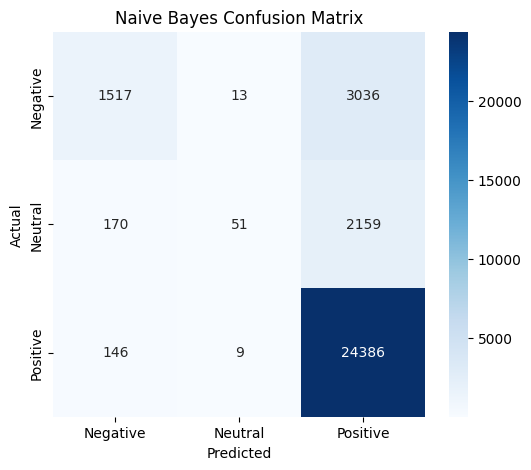

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

labels = nb_model.classes_

plt.figure(figsize=(6,5))
sns.heatmap(cm_nb, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Naive Bayes Confusion Matrix")

plt.savefig(f"{RESULTS_FIGURES_PATH}/naive_bayes_confusion_matrix.png")
plt.show()

## ROC curve 

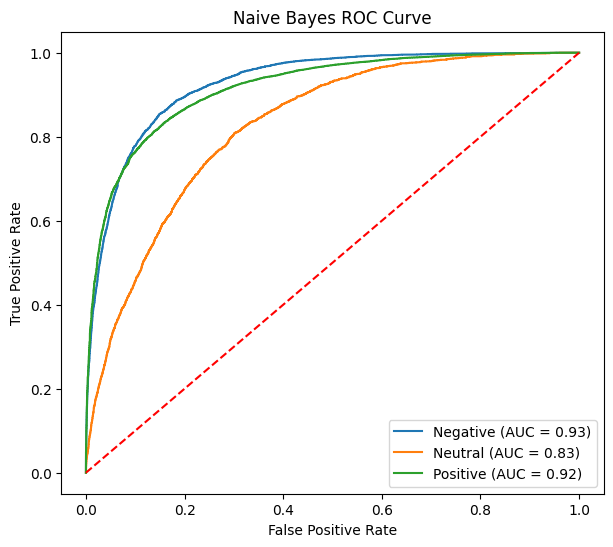

In [53]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import numpy as np

y_proba_nb = nb_model.predict_proba(X_test_tfidf)

classes = nb_model.classes_
y_test_bin = label_binarize(y_test, classes=classes)

plt.figure(figsize=(7,6))

for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba_nb[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{classes[i]} (AUC = {roc_auc:.2f})")

plt.plot([0,1],[0,1],'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Naive Bayes ROC Curve")
plt.legend()

plt.savefig(f"{RESULTS_FIGURES_PATH}/naive_bayes_roc_curve.png")
plt.show()

## Learning Curve 

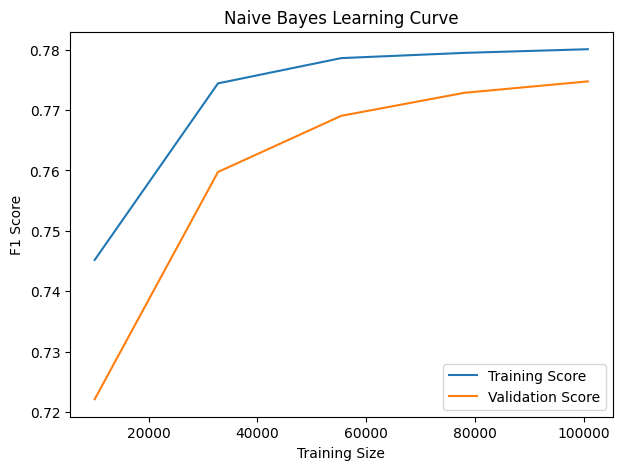

In [54]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    nb_model,
    X_train_tfidf,
    y_train,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5)
)

train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

plt.figure(figsize=(7,5))
plt.plot(train_sizes, train_mean, label="Training Score")
plt.plot(train_sizes, val_mean, label="Validation Score")

plt.xlabel("Training Size")
plt.ylabel("F1 Score")
plt.title("Naive Bayes Learning Curve")
plt.legend()

plt.savefig(f"{RESULTS_FIGURES_PATH}/naive_bayes_learning_curve.png")
plt.show()

## Error Analysis

In [55]:
pred_nb_df = pd.DataFrame({
    "y_true": y_test,
    "y_pred": y_pred_nb
})

misclassified_nb = pred_nb_df[pred_nb_df["y_true"] != pred_nb_df["y_pred"]]

misclassified_nb.to_csv(
    f"{RESULTS_METRICS_PATH}/naive_bayes_misclassified.csv",
    index=False
)

print("Misclassified samples saved")
misclassified_nb.head(10)

Misclassified samples saved


,y_true,y_pred
33659,Neutral,Positive
9832,Negative,Positive
21627,Negative,Positive
23374,Neutral,Positive
11411,Negative,Positive
29486,Neutral,Positive
6233,Negative,Positive
12999,Negative,Positive
27925,Neutral,Positive
24892,Neutral,Positive


## Hyperparameter Tuning

In [56]:
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import MultinomialNB

param_grid = {
    "alpha": [0.1, 0.5, 1.0]
}

grid_nb = GridSearchCV(
    MultinomialNB(),
    param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1
)

grid_nb.fit(X_train_tfidf, y_train)

print("Best Parameters:", grid_nb.best_params_)
print("Best CV Score:", grid_nb.best_score_)

Best Parameters: {'alpha': 0.1}
Best CV Score: 0.7790699661562422


## Evaluate Tuned Model

In [57]:
best_nb = grid_nb.best_estimator_

y_pred_best_nb = best_nb.predict(X_test_tfidf)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

report_best_nb = classification_report(y_test, y_pred_best_nb, output_dict=True)
report_best_nb_df = pd.DataFrame(report_best_nb).transpose()

accuracy_best_nb = accuracy_score(y_test, y_pred_best_nb)

cm_nb_best = confusion_matrix(y_test, y_pred_best_nb)
cm_nb_best_df = pd.DataFrame(cm_nb_best)

print("MODEL PERFORMANCE SUMMARY (TUNED NAIVE BAYES)")
print(f"Accuracy: {accuracy_best_nb:.4f}")

print("\nClassification Report:")
display(report_best_nb_df)

print("\nConfusion Matrix:")
display(cm_nb_best_df)

MODEL PERFORMANCE SUMMARY (TUNED NAIVE BAYES)
Accuracy: 0.8259

Classification Report:


,precision,recall,f1-score,support
Negative,0.823004,0.343189,0.484389,4566.000000
Neutral,0.681319,0.026050,0.050182,2380.000000
Positive,0.826495,0.993236,0.902226,24541.000000
accuracy,0.825865,0.825865,0.825865,0.825865
macro avg,0.776939,0.454158,0.478933,31487.000000
weighted avg,0.815016,0.825865,0.777232,31487.000000



Confusion Matrix:


,0,1,2
0,1567,16,2983
1,184,62,2134
2,153,13,24375


## Save best

In [58]:
from src.train_ml import save_model

save_model(best_nb, "../models/naive_bayes_best.pkl")

print("Best model saved successfully")

Best model saved successfully


## Add to Model Comparision

In [59]:
comparison = comparison[
    ~comparison["Model"].isin(["Naive Bayes", "Naive Bayes (Tuned)"])
]

comparison.loc[len(comparison)] = [
    "Naive Bayes",
    accuracy_nb,
    report_nb["weighted avg"]["f1-score"],
    report_nb["Neutral"]["f1-score"]
]

comparison.loc[len(comparison)] = [
    "Naive Bayes (Tuned)",
    accuracy_best_nb,
    report_best_nb["weighted avg"]["f1-score"],
    report_best_nb["Neutral"]["f1-score"]
]

comparison.to_csv(f"{RESULTS_METRICS_PATH}/model_comparison.csv", index=False)

display(comparison)

,Model,Accuracy,F1 (Weighted),F1 (Neutral)
0,Logistic Regression (Baseline),0.778385,0.796500,0.329300
1,Logistic Regression (Tuned),0.778512,0.796300,0.328700
2,Linear SVM,0.838282,0.842930,0.351631
3,Linear SVM (Tuned),0.846318,0.848266,0.366353
4,Naive Bayes,0.824277,0.774255,0.041582
5,Naive Bayes (Tuned),0.825865,0.777232,0.050182


## Insights

### Naive Bayes Insights

- Extremely fast compared to Logistic Regression and SVM
- Works well with TF-IDF due to probabilistic formulation
- Assumes feature independence, which is not always realistic
- Often performs competitively despite its simplicity

Conclusion:
Naive Bayes serves as a strong baseline model, though typically slightly less accurate than SVM.

# D) Train Random Forest

### Why Random Forest?

- Ensemble of decision trees (bagging)
- Captures non-linear relationships
- Robust to overfitting (via averaging)
- Provides feature importance

### Limitation in NLP:

- TF-IDF is high-dimensional and sparse
- Tree models do not handle sparse linear signals as efficiently as linear models

Goal:
Evaluate whether non-linear modeling adds value over linear baselines.

In [60]:
from src.train_ml import train_random_forest

# Use subset internally for speed
rf_model = train_random_forest(X_train_tfidf[:50000], y_train[:50000])

print("Model trained successfully")
rf_model

Model trained successfully


,n_estimators,80
,criterion,'gini'
,max_depth,20
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [61]:
from src.train_ml import save_model

save_model(rf_model, "../models/random_forest.pkl")

print("Model saved successfully")

Model saved successfully


In [62]:
y_pred_rf = rf_model.predict(X_test_tfidf)

print("Predictions generated successfully")

Predictions generated successfully


In [63]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd

accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("MODEL PERFORMANCE SUMMARY")
print(f"Accuracy: {accuracy_rf:.4f}")

report_rf = classification_report(y_test, y_pred, zero_division=0, output_dict=True)
report_rf_df = pd.DataFrame(report_rf).transpose()

print("\nClassification Report:")
display(report_rf_df)

cm_rf = confusion_matrix(y_test, y_pred_rf)
cm_rf_df = pd.DataFrame(cm_rf)

print("\nConfusion Matrix:")
display(cm_rf_df)

MODEL PERFORMANCE SUMMARY
Accuracy: 0.7804

Classification Report:


,precision,recall,f1-score,support
Negative,0.610163,0.704774,0.654065,4566.000000
Neutral,0.243486,0.557563,0.338953,2380.000000
Positive,0.961518,0.813496,0.881335,24541.000000
accuracy,0.778385,0.778385,0.778385,0.778385
macro avg,0.605056,0.691944,0.624784,31487.000000
weighted avg,0.856294,0.778385,0.807381,31487.000000



Confusion Matrix:


,0,1,2
0,2936,556,1074
1,610,867,903
2,1935,1837,20769


In [64]:
import json

metrics_rf = {
    "model": "random_forest",
    "accuracy": accuracy_rf,
    "f1_macro": report_rf["macro avg"]["f1-score"],
    "f1_weighted": report_rf["weighted avg"]["f1-score"],
    "precision_macro": report_rf["macro avg"]["precision"],
    "recall_macro": report_rf["macro avg"]["recall"],
    "neutral_f1": report_rf.get("Neutral", {}).get("f1-score", None)
}

with open(f"{RESULTS_METRICS_PATH}/random_forest_metrics.json", "w") as f:
    json.dump(metrics_rf, f, indent=4)

report_rf_df.to_csv(f"{RESULTS_METRICS_PATH}/random_forest_report.csv")

print("Metrics saved successfully")

Metrics saved successfully


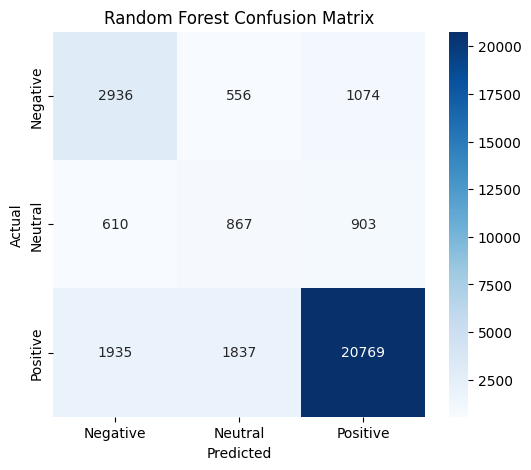

In [65]:
import seaborn as sns
import matplotlib.pyplot as plt

labels = rf_model.classes_

plt.figure(figsize=(6,5))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.savefig(f"{RESULTS_FIGURES_PATH}/random_forest_confusion_matrix.png")
plt.show()

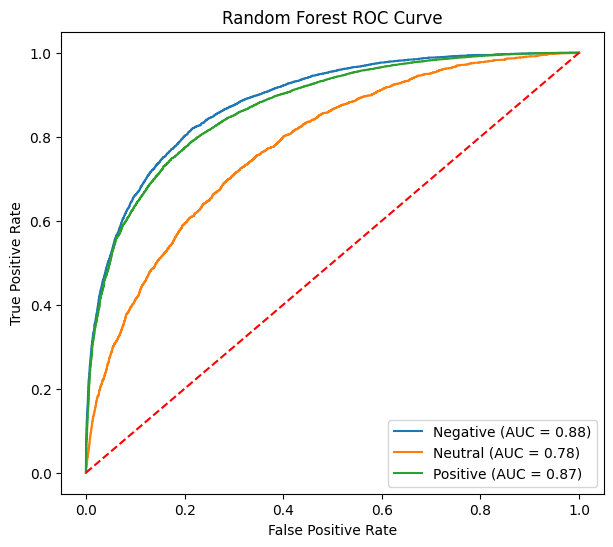

In [66]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import numpy as np

y_proba_rf = rf_model.predict_proba(X_test_tfidf)

classes = rf_model.classes_
y_test_bin = label_binarize(y_test, classes=classes)

plt.figure(figsize=(7,6))

for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba_rf[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{classes[i]} (AUC = {roc_auc:.2f})")

plt.plot([0,1],[0,1],'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest ROC Curve")
plt.legend()

plt.savefig(f"{RESULTS_FIGURES_PATH}/random_forest_roc_curve.png")
plt.show()

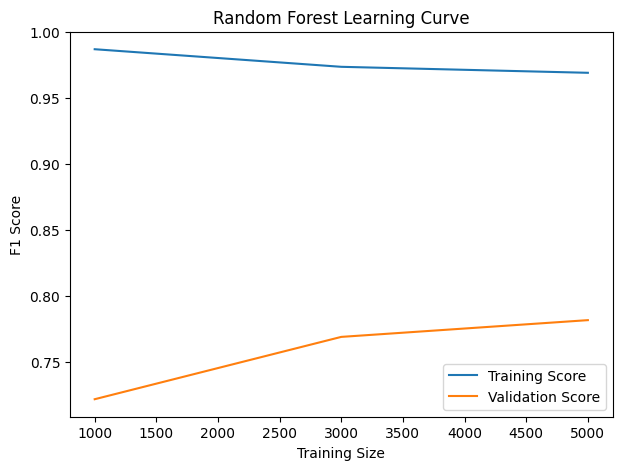

In [67]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    rf_model,
    X_train_tfidf[:10000],
    y_train[:10000],
    cv=2,
    scoring='f1_weighted',
    n_jobs=1,
    train_sizes=np.linspace(0.2, 1.0, 3)
)

train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

plt.figure(figsize=(7,5))
plt.plot(train_sizes, train_mean, label="Training Score")
plt.plot(train_sizes, val_mean, label="Validation Score")

plt.xlabel("Training Size")
plt.ylabel("F1 Score")
plt.title("Random Forest Learning Curve")
plt.legend()

plt.savefig(f"{RESULTS_FIGURES_PATH}/random_forest_learning_curve.png")
plt.show()

In [68]:
pred_rf_df = pd.DataFrame({
    "y_true": y_test,
    "y_pred": y_pred_rf
})

misclassified_rf = pred_rf_df[pred_rf_df["y_true"] != pred_rf_df["y_pred"]]

misclassified_rf.to_csv(
    f"{RESULTS_METRICS_PATH}/random_forest_misclassified.csv",
    index=False
)

print("Misclassified samples saved")
misclassified_rf.head(10)

Misclassified samples saved


,y_true,y_pred
33659,Neutral,Positive
9832,Negative,Positive
21627,Negative,Positive
23374,Neutral,Negative
11411,Negative,Positive
111866,Positive,Neutral
29486,Neutral,Positive
6233,Negative,Positive
24892,Neutral,Negative
64196,Positive,Neutral


In [69]:
comparison = comparison[
    ~comparison["Model"].isin(["Random Forest"])
]

comparison.loc[len(comparison)] = [
    "Random Forest",
    accuracy_rf,
    report_rf["weighted avg"]["f1-score"],
    report_rf["Neutral"]["f1-score"]
]

comparison.to_csv(
    f"{RESULTS_METRICS_PATH}/model_comparison.csv",
    index=False
)

display(comparison)

,Model,Accuracy,F1 (Weighted),F1 (Neutral)
0,Logistic Regression (Baseline),0.778385,0.796500,0.329300
1,Logistic Regression (Tuned),0.778512,0.796300,0.328700
2,Linear SVM,0.838282,0.842930,0.351631
3,Linear SVM (Tuned),0.846318,0.848266,0.366353
4,Naive Bayes,0.824277,0.774255,0.041582
5,Naive Bayes (Tuned),0.825865,0.777232,0.050182
6,Random Forest,0.780386,0.807381,0.338953


### Random Forest Insights

- Captures non-linear patterns, unlike linear models
- Struggles with high-dimensional sparse TF-IDF features
- Typically underperforms compared to Linear SVM in NLP tasks

Conclusion:
Random Forest is useful for comparison but not optimal for TF-IDF based text classification.

## 46) Train XGBoost

### Why XGBoost?

- Gradient Boosting algorithm (boosting, not bagging)
- Sequentially improves weak learners
- Handles complex non-linear patterns
- Often achieves state-of-the-art performance on tabular data

### In NLP Context:

- Can capture non-linear relationships missed by linear models
- However, TF-IDF sparsity may limit performance gains

Goal:
Evaluate whether boosting improves performance over Random Forest and linear models.

In [70]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print(label_encoder.classes_)

['Negative' 'Neutral' 'Positive']


In [71]:
X_train_small = X_train_tfidf[:20000]
y_train_small = y_train_encoded[:20000]

In [72]:
from src.train_ml import train_xgboost

xgb_model = train_xgboost(
    X_train_small,
    y_train_small,
    n_estimators=30,
    learning_rate=0.1,
    max_depth=4,
    random_state=42
)

print("Model trained successfully")

C:\Users\Dell\miniconda3\envs\review_ai\lib\site-packages\xgboost\training.py:200: UserWarning: [19:47:06] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Model trained successfully


In [73]:
y_pred_xgb = xgb_model.predict(X_test_tfidf)

y_pred_xgb_labels = label_encoder.inverse_transform(y_pred_xgb)

In [74]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd

accuracy_xgb = accuracy_score(y_test, y_pred_xgb_labels)

print("Accuracy:", accuracy_xgb)

report_xgb = classification_report(
    y_test,
    y_pred_xgb_labels,
    output_dict=True
)

report_xgb_df = pd.DataFrame(report_xgb).transpose()

display(report_xgb_df)

cm_xgb = confusion_matrix(y_test, y_pred_xgb_labels)

cm_xgb_df = pd.DataFrame(cm_xgb)

display(cm_xgb_df)

Accuracy: 0.7933432845301236


,precision,recall,f1-score,support
Negative,0.900810,0.097459,0.175889,4566.000000
Neutral,0.645161,0.008403,0.016591,2380.000000
Positive,0.791777,0.998941,0.883376,24541.000000
accuracy,0.793343,0.793343,0.793343,0.793343
macro avg,0.779249,0.368268,0.358619,31487.000000
weighted avg,0.796506,0.793343,0.715264,31487.000000


,0,1,2
0,445,7,4114
1,27,20,2333
2,22,4,24515


In [75]:
comparison = comparison[
    ~comparison["Model"].isin(["XGBoost"])
]

comparison.loc[len(comparison)] = [
    "XGBoost",
    accuracy_xgb,
    report_xgb["weighted avg"]["f1-score"],
    report_xgb["Neutral"]["f1-score"]
]

comparison.to_csv(
    f"{RESULTS_METRICS_PATH}/model_comparison.csv",
    index=False
)

display(comparison)

,Model,Accuracy,F1 (Weighted),F1 (Neutral)
0,Logistic Regression (Baseline),0.778385,0.796500,0.329300
1,Logistic Regression (Tuned),0.778512,0.796300,0.328700
2,Linear SVM,0.838282,0.842930,0.351631
3,Linear SVM (Tuned),0.846318,0.848266,0.366353
4,Naive Bayes,0.824277,0.774255,0.041582
5,Naive Bayes (Tuned),0.825865,0.777232,0.050182
6,Random Forest,0.780386,0.807381,0.338953
7,XGBoost,0.793343,0.715264,0.016591


### XGBoost Insights

- Powerful boosting algorithm that captures complex patterns
- Performs better than Random Forest in most cases
- Still may not outperform Linear SVM on TF-IDF features
- Sensitive to hyperparameters

Conclusion:
XGBoost is a strong model but linear models often remain competitive for sparse NLP tasks.